# Export des figures pour le mémoire
Ce notebook recharge les artefacts (modèles + scaler + métadonnées) et **reproduit uniquement les figures** en les exportant en PNG (300 dpi) dans un dossier `figures_export/`.

➡️ Aucun ré-entraînement n'est effectué.

In [1]:
# =========================
# 0) Configuration des chemins
# =========================
CSV_PATH = "dataset_autoencoder_all.csv"  # <-- adapte si besoin

ART_AE  = "artifacts_ae"
ART_DAE = "artifacts_dae"
ART_SAE = "artifacts_sae"

FIG_DIR = "figures_export"  # dossier de sortie des figures

In [2]:
# =========================
# 1) Imports & device
# =========================
import os, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE, "| torch:", torch.__version__)

os.makedirs(FIG_DIR, exist_ok=True)

DEVICE: cpu | torch: 2.8.0+cu128


In [3]:
# --- Architectures AE / DAE / SAE (héritage) ---

def add_gaussian_noise(x: torch.Tensor, std: float) -> torch.Tensor:
    """Ajoute un bruit gaussien N(0, std^2) (utilisé par le DAE)."""
    if std <= 0:
        return x
    return x + torch.randn_like(x) * std


class MLP_AE(nn.Module):
    """Autoencodeur dense de base (baseline)."""

    def __init__(self, in_dim: int, latent_dim: int = 8, dropout: float = 0.1):
        super().__init__()
        self.in_dim = in_dim
        self.latent_dim = latent_dim
        self.dropout = dropout

        # Encoder / decoder identiques à la version initiale (choix d'ingénierie conservés)
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 24),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(24, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 24),
            nn.ReLU(),
            nn.Linear(24, in_dim),
        )

    # --- Points d'extension (pour éviter la duplication AE/DAE/SAE) ---
    def preprocess(self, x: torch.Tensor, train: bool) -> torch.Tensor:
        """Pré-traitement éventuel de l'entrée (DAE ajoute du bruit en entraînement)."""
        return x

    def extra_loss(self, z: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Terme de pénalité éventuel (SAE ajoute une pénalité de parcimonie)."""
        return torch.zeros((), device=x.device)

    # --- API commune ---
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encode(x)
        return self.decode(z)


class MLP_DAE(MLP_AE):
    """Denoising Autoencoder : même architecture que AE, mais entrée bruitée (train)."""

    def __init__(self, in_dim: int, latent_dim: int = 8, dropout: float = 0.1, noise_std: float = 0.05):
        super().__init__(in_dim=in_dim, latent_dim=latent_dim, dropout=dropout)
        self.noise_std = noise_std

    def preprocess(self, x: torch.Tensor, train: bool) -> torch.Tensor:
        return add_gaussian_noise(x, self.noise_std) if train else x


class MLP_SAE(MLP_AE):
    """Sparse Autoencoder : même architecture que AE, + pénalité L1 sur le latent."""

    def __init__(self, in_dim: int, latent_dim: int = 8, dropout: float = 0.1, l1_lambda: float = 1e-3):
        super().__init__(in_dim=in_dim, latent_dim=latent_dim, dropout=dropout)
        self.l1_lambda = l1_lambda

    def extra_loss(self, z: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        # pénalité L1 moyenne sur le latent (choix simple + stable numériquement)
        return self.l1_lambda * torch.mean(torch.abs(z))


In [4]:
# =========================
# 2) Chargement des artefacts (scaler, métadonnées, poids)
# =========================
meta_ae  = joblib.load(os.path.join(ART_AE,  "meta.joblib"))
meta_dae = joblib.load(os.path.join(ART_DAE, "meta_dae.joblib"))
meta_sae = joblib.load(os.path.join(ART_SAE, "meta_sae.joblib"))

scaler = joblib.load(os.path.join(ART_AE, "scaler.joblib"))

threshold_ae  = float(meta_ae["threshold_value"])
threshold_dae = float(meta_dae["threshold_value"])
threshold_sae = float(meta_sae["threshold_value"])

feature_cols  = list(meta_ae["feature_cols"])
entropy_cols  = list(meta_ae.get("entropy_cols", []))
log_cols      = list(meta_ae.get("log_cols", []))

print("Nb features:", len(feature_cols))
print("Seuils:", "AE=", threshold_ae, "| DAE=", threshold_dae, "| SAE=", threshold_sae)

Nb features: 36
Seuils: AE= 4.389127254486084 | DAE= 4.146695613861084 | SAE= 4.262524604797363


In [5]:
# =========================
# 3) Chargement du dataset + prétraitement identique à l'entraînement
# =========================
df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)

# temps conservé pour les plots temporels
if "window_start" in df.columns:
    df["window_start"] = pd.to_datetime(df["window_start"], errors="coerce")
else:
    df["window_start"] = pd.NaT

# Vérification colonnes attendues
missing = [c for c in feature_cols if c not in df.columns]
extra   = [c for c in df.columns if c not in (["window_start"] + feature_cols)]
print("Missing features:", len(missing))
if missing[:10]:
    print("Exemples missing:", missing[:10])
print("Extra columns (ignorées):", len(extra))

# Construction X_raw dans le même ordre que l'entraînement
X_raw = df[feature_cols].copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Règles de prétraitement (comme dans le notebook d'origine)
X = X_raw.copy()

# a) clipping des entropies
for c in entropy_cols:
    if c in X.columns:
        X[c] = X[c].clip(lower=0.0)

# b) log1p sur les colonnes listées (log_cols déjà validées à l'entraînement)
for c in log_cols:
    if c in X.columns:
        X[c] = np.log1p(X[c].astype(np.float64))

X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# scaling
X_all_s = scaler.transform(X).astype(np.float32)
print("X_all_s:", X_all_s.shape)

Dataset shape: (13641, 37)
Missing features: 0
Extra columns (ignorées): 0
X_all_s: (13641, 36)


In [6]:
# =========================
# 4) Split train/val/test identique (pour histogrammes val vs test)
# =========================
from sklearn.model_selection import train_test_split

X_train, X_tmp = train_test_split(X, test_size=0.30, random_state=SEED, shuffle=True)
X_val, X_test  = train_test_split(X_tmp, test_size=0.50, random_state=SEED, shuffle=True)

X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

print("Train/Val/Test:", X_train_s.shape, X_val_s.shape, X_test_s.shape)

BATCH_SIZE = 128
NUM_WORKERS = 0

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train_s)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val_s)),   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test_s)),  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Train/Val/Test: (9548, 36) (2046, 36) (2047, 36)


In [7]:
# =========================
# 5) Instanciation des modèles + chargement des state_dict
# =========================
in_dim = X_train_s.shape[1]
LATENT_DIM = int(meta_ae.get("latent_dim", 8))
DROPOUT = float(meta_ae.get("dropout", 0.1))
NOISE_STD = float(meta_dae.get("noise_std", 0.05))
L1_LAMBDA = float(meta_sae.get("l1_lambda", 1e-3))

model_ae  = MLP_AE(in_dim=in_dim, latent_dim=LATENT_DIM, dropout=DROPOUT).to(DEVICE)
model_dae = MLP_DAE(in_dim=in_dim, latent_dim=LATENT_DIM, dropout=DROPOUT, noise_std=NOISE_STD).to(DEVICE)
model_sae = MLP_SAE(in_dim=in_dim, latent_dim=LATENT_DIM, dropout=DROPOUT, l1_lambda=L1_LAMBDA).to(DEVICE)

model_ae.load_state_dict(torch.load(os.path.join(ART_AE,  "mlp_ae_lat8.pt"),  map_location=DEVICE))
model_dae.load_state_dict(torch.load(os.path.join(ART_DAE, "mlp_dae_lat8.pt"), map_location=DEVICE))
model_sae.load_state_dict(torch.load(os.path.join(ART_SAE, "mlp_sae_lat8.pt"), map_location=DEVICE))

model_ae.eval(); model_dae.eval(); model_sae.eval()
print("Models loaded ✅")

Models loaded ✅


In [8]:
# =========================
# 6) Utilitaires : erreurs + plots (avec export PNG)
# =========================
@torch.no_grad()
def reconstruction_errors(model, loader):
    model.eval()
    errs = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        x_hat = model(xb)
        e = torch.mean((x_hat - xb) ** 2, dim=1)
        errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs, axis=0)

@torch.no_grad()
def reconstruction_errors_array(model, Xs: np.ndarray, batch_size: int = 512):
    model.eval()
    errs = []
    for i in range(0, Xs.shape[0], batch_size):
        xb = torch.from_numpy(Xs[i:i+batch_size]).to(DEVICE)
        x_hat = model(xb)
        e = torch.mean((x_hat - xb) ** 2, dim=1)
        errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs, axis=0)

def make_df_vis(df, recon_err, threshold):
    df_vis = df[["window_start"]].copy()
    df_vis["recon_error"] = recon_err
    df_vis["is_anomaly"] = (df_vis["recon_error"] > threshold).astype(int)
    df_vis = df_vis.sort_values("window_start").reset_index(drop=True)
    df_vis["win_idx"] = np.arange(len(df_vis))
    return df_vis

def save_current_fig(filename: str):
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

def plot_hist(val_err, test_err, threshold, title, filename):
    plt.figure()
    plt.hist(val_err, bins=60, alpha=0.6, label="Validation")
    plt.hist(test_err, bins=60, alpha=0.6, label="Test")
    plt.axvline(threshold, linewidth=2, label=f"Seuil = {threshold:.4f}")
    plt.xlabel("Erreur de reconstruction (MSE par fenêtre)")
    plt.ylabel("Nombre de fenêtres")
    plt.title(title)
    plt.legend()
    save_current_fig(filename)
    plt.show()

def plot_time_index(df_vis, threshold, title, filename):
    anom = df_vis[df_vis["is_anomaly"] == 1]
    plt.figure()
    plt.plot(df_vis["win_idx"], df_vis["recon_error"], linewidth=1, label="Erreur")
    plt.axhline(threshold, linewidth=2, label="Seuil")
    if len(anom) > 0:
        plt.scatter(anom["win_idx"], anom["recon_error"], s=20, label=f"Anomalies ({len(anom)})")
    plt.xlabel("Index de fenêtre (ordre temporel)")
    plt.ylabel("Erreur de reconstruction")
    plt.title(title)
    plt.legend()
    save_current_fig(filename)
    plt.show()
    return anom

def plot_rate_per_hour(df_vis, title, filename):
    df_rate = df_vis.dropna(subset=["window_start"]).copy().set_index("window_start")
    rate_h = df_rate["is_anomaly"].resample("1h").mean()
    plt.figure()
    plt.plot(rate_h.index, rate_h.values, linewidth=1)
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.xlabel("Temps")
    plt.ylabel("Taux d'anomalies (moyenne horaire)")
    plt.title(title)
    plt.tight_layout()
    save_current_fig(filename)
    plt.show()

Saved: figures_export/fig_4_1_hist_AE.png


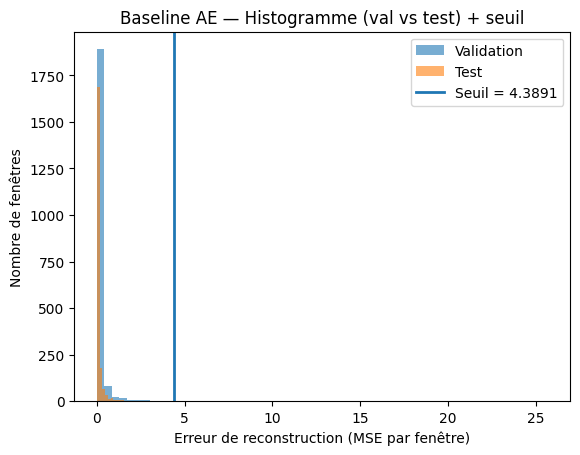

Saved: figures_export/fig_4_2_timeindex_AE.png


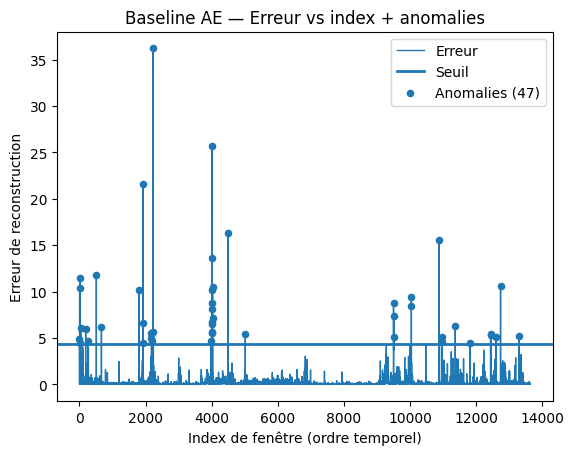

Saved: figures_export/fig_4_3_rate_AE.png


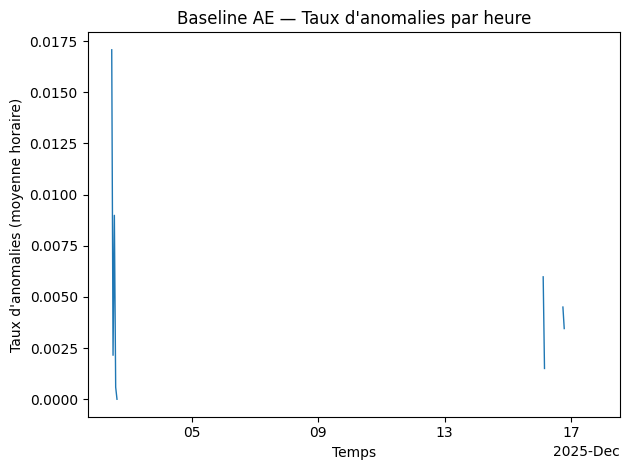

Nb anomalies AE (tout dataset): 47


In [9]:
# =========================
# 7) Figures — AE
# =========================
val_err_ae  = reconstruction_errors(model_ae,  val_loader)
test_err_ae = reconstruction_errors(model_ae, test_loader)

all_err_ae = reconstruction_errors_array(model_ae, X_all_s)
df_vis_ae  = make_df_vis(df, all_err_ae, threshold_ae)

plot_hist(val_err_ae, test_err_ae, threshold_ae,
          title="Baseline AE — Histogramme (val vs test) + seuil",
          filename="fig_4_1_hist_AE.png")

_ = plot_time_index(df_vis_ae, threshold_ae,
                    title="Baseline AE — Erreur vs index + anomalies",
                    filename="fig_4_2_timeindex_AE.png")

plot_rate_per_hour(df_vis_ae,
                   title="Baseline AE — Taux d'anomalies par heure",
                   filename="fig_4_3_rate_AE.png")

print("Nb anomalies AE (tout dataset):", int(df_vis_ae["is_anomaly"].sum()))

Saved: figures_export/fig_4_4_hist_DAE.png


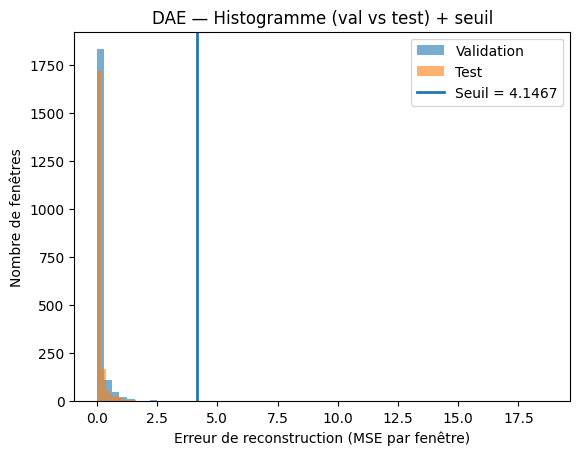

Saved: figures_export/fig_4_5_timeindex_DAE.png


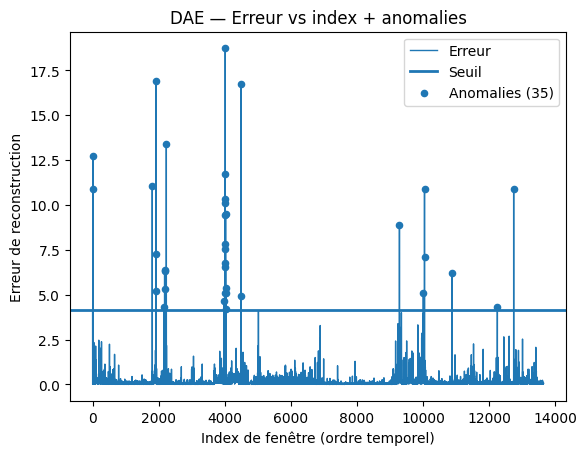

Saved: figures_export/fig_4_6_rate_DAE.png


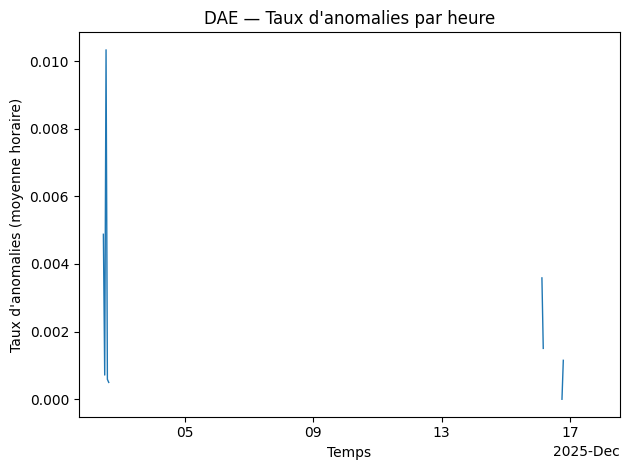

Nb anomalies DAE (tout dataset): 35


In [10]:
# =========================
# 8) Figures — DAE
# =========================
val_err_dae  = reconstruction_errors(model_dae,  val_loader)
test_err_dae = reconstruction_errors(model_dae, test_loader)

all_err_dae = reconstruction_errors_array(model_dae, X_all_s)
df_vis_dae  = make_df_vis(df, all_err_dae, threshold_dae)

plot_hist(val_err_dae, test_err_dae, threshold_dae,
          title="DAE — Histogramme (val vs test) + seuil",
          filename="fig_4_4_hist_DAE.png")

_ = plot_time_index(df_vis_dae, threshold_dae,
                    title="DAE — Erreur vs index + anomalies",
                    filename="fig_4_5_timeindex_DAE.png")

plot_rate_per_hour(df_vis_dae,
                   title="DAE — Taux d'anomalies par heure",
                   filename="fig_4_6_rate_DAE.png")

print("Nb anomalies DAE (tout dataset):", int(df_vis_dae["is_anomaly"].sum()))

Saved: figures_export/fig_4_7_timeindex_SAE.png


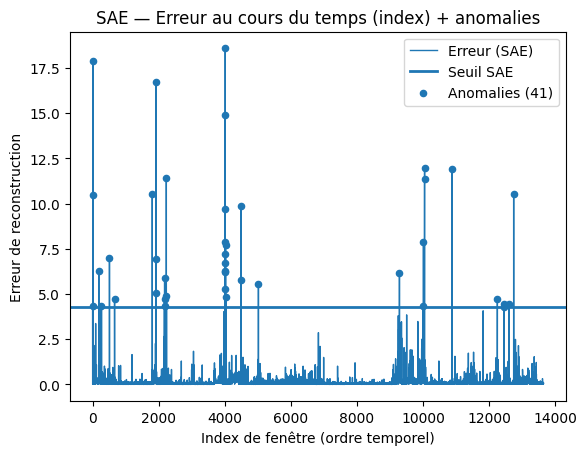

Saved: figures_export/fig_4_8_rate_SAE.png


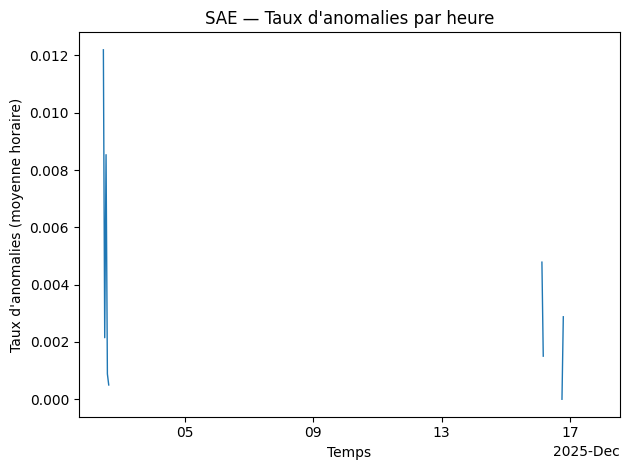

Nb anomalies SAE: 41
Saved: figures_export/fig_4_10_hist_SAE.png


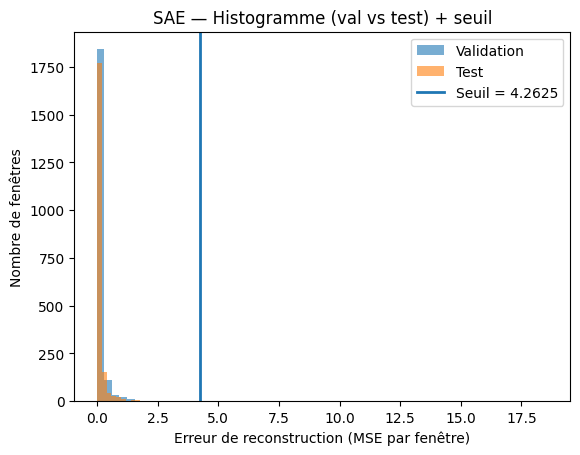

In [11]:
# =========================
# 9) Figures — SAE
# =========================
all_err_sae = reconstruction_errors_array(model_sae, X_all_s)
df_vis_sae  = make_df_vis(df, all_err_sae, threshold_sae)

anom_sae = df_vis_sae[df_vis_sae["is_anomaly"] == 1]

plt.figure()
plt.plot(df_vis_sae["win_idx"], df_vis_sae["recon_error"], linewidth=1, label="Erreur (SAE)")
plt.axhline(threshold_sae, linewidth=2, label="Seuil SAE")
if len(anom_sae) > 0:
    plt.scatter(anom_sae["win_idx"], anom_sae["recon_error"], s=20, label=f"Anomalies ({len(anom_sae)})")
plt.xlabel("Index de fenêtre (ordre temporel)")
plt.ylabel("Erreur de reconstruction")
plt.title("SAE — Erreur au cours du temps (index) + anomalies")
plt.legend()
save_current_fig("fig_4_7_timeindex_SAE.png")
plt.show()

# Taux horaire
df_rate = df_vis_sae.dropna(subset=["window_start"]).copy().set_index("window_start")
rate_h = df_rate["is_anomaly"].resample("1h").mean()

plt.figure()
plt.plot(rate_h.index, rate_h.values, linewidth=1)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xlabel("Temps")
plt.ylabel("Taux d'anomalies (moyenne horaire)")
plt.title("SAE — Taux d'anomalies par heure")
plt.tight_layout()
save_current_fig("fig_4_8_rate_SAE.png")
plt.show()

print("Nb anomalies SAE:", len(anom_sae))


# =========================
# Figures — SAE (Histogramme)
# =========================
val_err_sae  = reconstruction_errors(model_sae, val_loader)
test_err_sae = reconstruction_errors(model_sae, test_loader)

plot_hist(
    val_err_sae,
    test_err_sae,
    threshold_sae,
    title="SAE — Histogramme (val vs test) + seuil",
    filename="fig_4_10_hist_SAE.png"
)


Saved: figures_export/fig_4_9_comparaison_AE_DAE_SAE.png


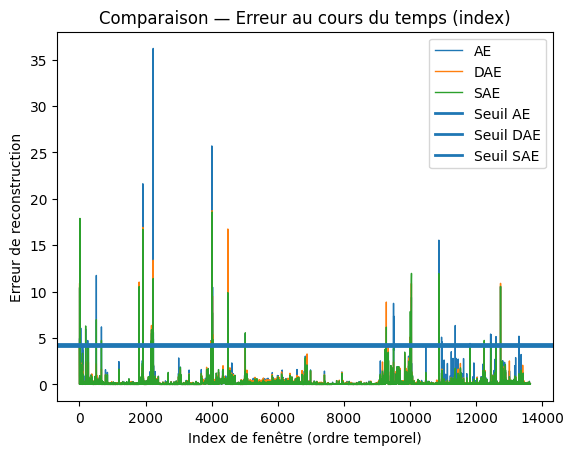

In [12]:
# =========================
# 10) Figure — comparaison AE/DAE/SAE
# =========================
plt.figure()
plt.plot(df_vis_ae["win_idx"],  df_vis_ae["recon_error"],  linewidth=1, label="AE")
plt.plot(df_vis_dae["win_idx"], df_vis_dae["recon_error"], linewidth=1, label="DAE")
plt.plot(df_vis_sae["win_idx"], df_vis_sae["recon_error"], linewidth=1, label="SAE")

plt.axhline(threshold_ae,  linewidth=2, label="Seuil AE")
plt.axhline(threshold_dae, linewidth=2, label="Seuil DAE")
plt.axhline(threshold_sae, linewidth=2, label="Seuil SAE")

plt.xlabel("Index de fenêtre (ordre temporel)")
plt.ylabel("Erreur de reconstruction")
plt.title("Comparaison — Erreur au cours du temps (index)")
plt.legend()
save_current_fig("fig_4_9_comparaison_AE_DAE_SAE.png")
plt.show()